In [1]:
import polars as pl

df = pl.read_parquet("data/formatted/xnas_itch_mbo.parquet")

df.head()

ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
"datetime[ns, UTC]",u8,u16,u32,str,str,f64,u32,u8,u64,u8,i32,u32,str
2025-09-30 07:05:02.706090672 UTC,160,2,13258,"""R""","""N""",null,0,0,0,8,0,0,"""QBTS"""
2025-09-30 08:00:00.009467334 UTC,160,2,13258,"""A""","""A""",35.3,1400,0,1075,128,170611,294040,"""QBTS"""
2025-09-30 08:00:00.025941082 UTC,160,2,13258,"""A""","""A""",25.67,10,0,3107,128,163805,295190,"""QBTS"""
2025-09-30 08:00:00.025973448 UTC,160,2,13258,"""A""","""A""",25.37,5,0,3119,128,163371,295195,"""QBTS"""
2025-09-30 08:00:00.027132817 UTC,160,2,13258,"""T""","""B""",25.37,5,0,0,128,164634,295317,"""QBTS"""


In [2]:
df.describe()

statistic,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
str,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str
"""count""","""46821018""",4.6821018e7,4.6821018e7,4.6821018e7,"""46821018""","""46821018""",4.6820994e7,4.6821018e7,4.6821018e7,4.6821018e7,4.6821018e7,4.6821018e7,4.6821018e7,"""46821018"""
"""null_count""","""0""",0.0,0.0,0.0,"""0""","""0""",24.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""","""2025-10-15 23:53:04.462214+00:…",160.0,2.0,13258.0,null,null,35.393887,99.402079,0.0,5.6311e8,106.318544,164059.567989,4.2209e8,null
"""std""",null,0.0,0.0,0.0,null,null,350.847515,328.925799,0.0,3.7543e8,48.011878,21128.401318,2.6203e8,null
"""min""","""2025-09-30 07:05:02.706090+00:…",160.0,2.0,13258.0,"""A""","""A""",0.0001,0.0,0.0,0.0,0.0,0.0,0.0,"""QBTS"""
"""25%""","""2025-10-07 18:16:21.668009+00:…",160.0,2.0,13258.0,null,null,32.62,25.0,0.0,2.47086791e8,128.0,162930.0,2.03847875e8,null
"""50%""","""2025-10-15 14:36:56.310787+00:…",160.0,2.0,13258.0,null,null,34.67,50.0,0.0,5.37174607e8,128.0,163226.0,4.01241891e8,null
"""75%""","""2025-10-23 15:17:32.974976+00:…",160.0,2.0,13258.0,null,null,36.7,100.0,0.0,8.27911715e8,128.0,164161.0,5.96908037e8,null
"""max""","""2025-10-31 23:59:44.883003+00:…",160.0,2.0,13258.0,"""T""","""N""",199999.0,345096.0,0.0,1.8885e9,128.0,3.8042834e7,1.3945e9,"""QBTS"""


In [3]:
df["action"].value_counts(normalize=True)

action,proportion
str,f64
"""A""",0.450079
"""C""",0.458063
"""F""",0.040782
"""R""",5.1259e-7
"""T""",0.051075


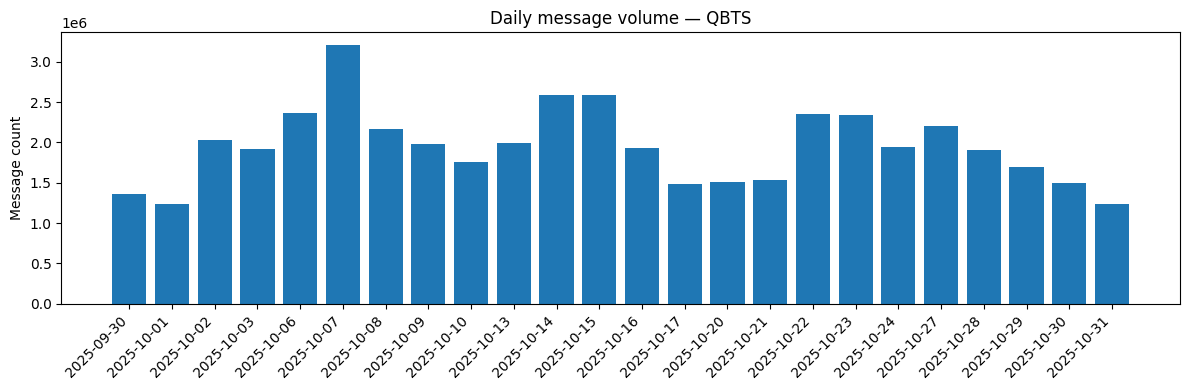

In [5]:
import matplotlib.pyplot as plt

daily = (
    df.with_columns(pl.col("ts_event").dt.date().alias("date"))
    .group_by("date")
    .len()
    .sort("date")
)

plt.figure(figsize=(12, 4))
plt.bar(daily["date"].cast(str), daily["len"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Message count")
plt.title("Daily message volume — QBTS")
plt.tight_layout()

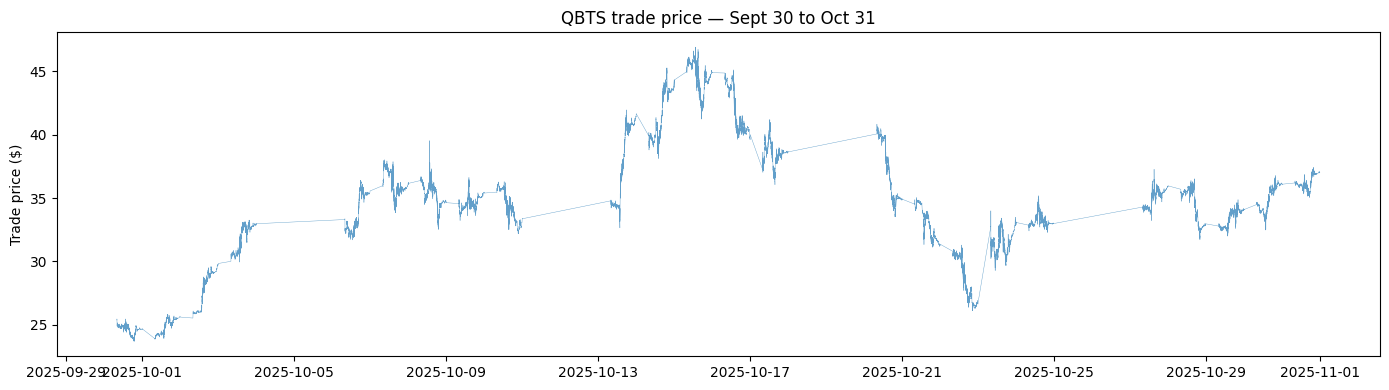

In [6]:
trades = df.filter(
    (pl.col("action") == "T") & (pl.col("price") > 1) & (pl.col("price") < 1000)
)

plt.figure(figsize=(14, 4))
plt.plot(trades["ts_event"], trades["price"], lw=0.3, alpha=0.7)
plt.ylabel("Trade price ($)")
plt.title("QBTS trade price — Sept 30 to Oct 31")
plt.tight_layout()

Text(0.5, 1.0, 'Message volume by hour of day')

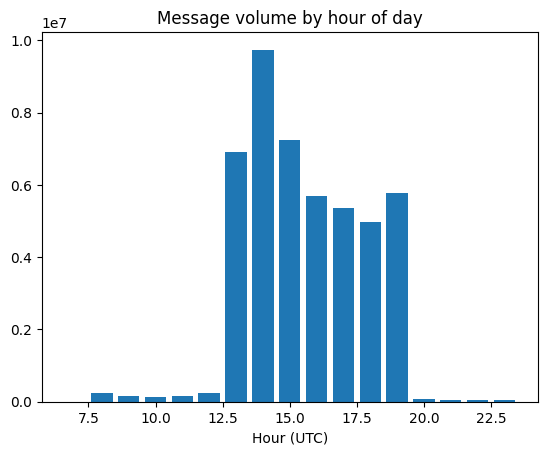

In [7]:
intraday = (
    df.with_columns(pl.col("ts_event").dt.hour().alias("hour"))
    .group_by("hour")
    .len()
    .sort("hour")
)
# UTC hours: 13=open (9:30 ET), 20=close (4pm ET)
plt.bar(intraday["hour"], intraday["len"])
plt.xlabel("Hour (UTC)")
plt.title("Message volume by hour of day")

In [8]:
cross = (
    df.filter(pl.col("action") != "R")
    .group_by(["action", "side"])
    .len()
    .pivot(on="side", index="action", values="len")
    .sort("action")
)
print(cross)

shape: (4, 4)
┌────────┬──────────┬──────────┬────────┐
│ action ┆ A        ┆ B        ┆ N      │
│ ---    ┆ ---      ┆ ---      ┆ ---    │
│ str    ┆ u32      ┆ u32      ┆ u32    │
╞════════╪══════════╪══════════╪════════╡
│ A      ┆ 10796360 ┆ 10276789 ┆ null   │
│ C      ┆ 10989943 ┆ 10457044 ┆ null   │
│ F      ┆ 955615   ┆ 953848   ┆ null   │
│ T      ┆ 953848   ┆ 955612   ┆ 481935 │
└────────┴──────────┴──────────┴────────┘


Text(0.5, 1.0, 'Order size distribution (log scale)')

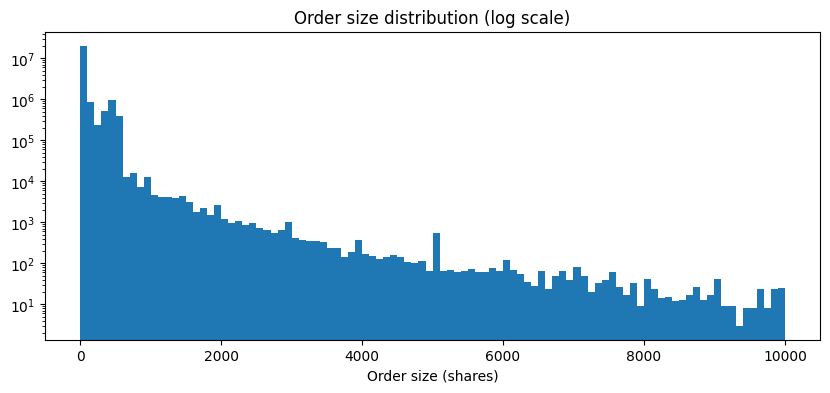

In [9]:
sizes = df.filter(
    (pl.col("action").is_in(["A", "T"]))
    & (pl.col("size") > 0)
    & (pl.col("size") < 10_000)
)["size"]

plt.figure(figsize=(10, 4))
plt.hist(sizes, bins=100, log=True)
plt.xlabel("Order size (shares)")
plt.title("Order size distribution (log scale)")

Text(0.5, 1.0, '1-minute VWAP — QBTS')

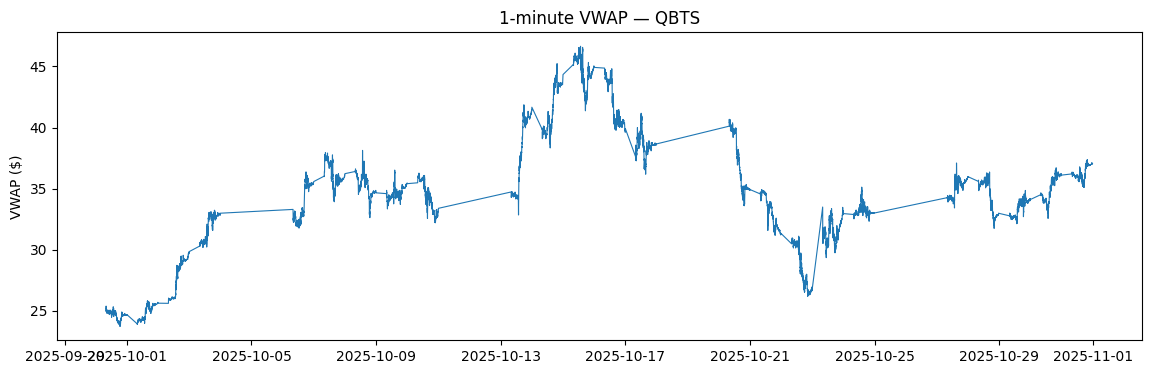

In [ ]:
vwap = (
    trades.with_columns(pl.col("ts_event").dt.truncate("1m").alias("minute"))
    .group_by("minute")
    .agg(
        [
            (pl.col("price") * pl.col("size")).sum().alias("pv"),
            pl.col("size").sum().alias("vol"),
        ]
    )
    .with_columns((pl.col("pv") / pl.col("vol")).alias("vwap"))
    .sort("minute")
)

plt.figure(figsize=(14, 4))
plt.plot(vwap["minute"], vwap["vwap"], lw=0.8)
plt.ylabel("VWAP ($)")
plt.title("1-minute VWAP — QBTS")